# S6E9: FT-Transformer (Feature Tokenizer Transformer)
Treating Tabular Data exactly like an LLM treats text. This pushes both numerical and categorical features into a massive Self-Attention space.
If you find this powerful, please upvote!

In [1]:
try:
    from colorama import Fore, Style
except:
    %pip install -q colorama
    from colorama import Fore, Style

import os, sys
import pandas as pd
import numpy as np, random

import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import QuantileTransformer, OrdinalEncoder, LabelEncoder, KBinsDiscretizer, TargetEncoder

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 500)

print("Libraries loaded successfully.")

# def seed_everything(seed: int):
#     random.seed(seed)
#     np.random.seed(seed)
#     torch.manual_seed(seed)

def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # for multi-GPU setups
    
    # Enforce PyTorch deterministic operations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # Enable strict determinism in modern PyTorch versions
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(42)

Libraries loaded successfully.


In [2]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s6e9/test.csv")
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv')
orig = pd.read_csv("/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv")

print("Train shape:", train.shape)
print("Test shape :", test.shape)
print("Orig shape :", orig.shape)

Train shape: (668665, 15)
Test shape : (286571, 14)
Orig shape : (10000, 15)


In [3]:
%%time

ID = 'id'
TARGET = 'Will_Buy_EV'
train[TARGET] = train[TARGET].map({'No': 0, 'Yes': 1})
orig[TARGET] = orig[TARGET].map({'No': 0, 'Yes': 1})
X = train.drop([ID, TARGET], axis=1); train_id = train[ID]
y = train[TARGET]
X_test = test.drop([ID], axis=1); test_id = test[ID]
del train, test
print("X      init shape:", X.shape)
print("X_test init shape:", X_test.shape, "\n")

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
print("init len(cat_cols):", len(cat_cols))
print("init len(num_cols):", len(num_cols), "\n")

category_map = {}
important_combos = [
    ('Annual_Income_USD', 'Range_Anxiety_Level'),
    ('Age', 'Range_Anxiety_Level'),
    ('Annual_Income_USD', 'Income_/_100_floor_'),
]
def feature_engineering(df, fit=False):
    # Fill NaNs
    for col in cat_cols:
        df[col] = df[col].fillna("missing")
    for col in num_cols:
        df[col] = df[col].fillna(0.0)

    # Categorize string cats
    for col in cat_cols:
        if fit:
            codes, uniques = df[col].factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = df[col].map(code_map).fillna(-1).astype('int32')
        df[col] = codes
        df[col] = df[col].astype('category')

    # Arithmetic interaction
    df['_Daily_Commute_km_/_Age'] = (df['Daily_Commute_km'] / (df['Age'] + 1e-6)).astype('float32')
    df['Income_/_100_floor_'] = np.floor(df['Annual_Income_USD'] / 100.0).astype('float32').astype('category')
    df['Income_/_1000_floor_'] = np.floor(df['Annual_Income_USD'] / 1000.0).astype('float32').astype('category')
    df['Income_/_10000_floor_'] = np.floor(df['Annual_Income_USD'] / 10000.0).astype('float32').astype('category')
    df['Daily_km_/_5_floor_'] = np.floor(df['Daily_Commute_km'] / 5.0).astype('float32').astype('category')

    # Categorize numericals
    for col in [i for i in num_cols if i not in ['Annual_Income_USD', 'Charging_Stations_Near_Home']]:
        cat_name = f"{col}_cat_"
        if fit:
            codes, uniques = np.floor(df[col]).factorize()
            category_map[col] = uniques
        else:
            uniques = category_map[col]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = np.floor(df[col]).map(code_map).fillna(-1).astype('int32')
        df[cat_name] = codes
        df[cat_name] = df[cat_name].astype('category')

    # Digit extraction
    for col in ['Daily_Commute_km']:
        decimal_name = f"_{col}_decimal"
        df[decimal_name] = (df[col] % 1).round(2).astype('float32')
    df['Annual_Income_USD_is_multiple_10_'] = (np.floor(df['Annual_Income_USD']) % 10 == 0).astype('category')

    # Target encoding from orig
    for col in ['Annual_Income_USD']:
        orig_enc_name = f"_{col}_mean_target_orig"
        df[orig_enc_name] = (
            df[col]
            .map(orig.groupby(col)[TARGET].mean())
            .fillna(orig[TARGET].mean())
            .astype('float32')
        )

    # Count encoding
    for col in ['Annual_Income_USD']:
        count_name = f"_{col}_count"
        if fit:
            count_map = df[col].value_counts()
            category_map[count_name] = count_map
        else:
            count_map = category_map[count_name]
        df[count_name] = df[col].astype(object).map(count_map).fillna(0).astype('int32')

    # Discretize numericals
    bin_config = {'Annual_Income_USD': [400, 600, 800, 900, 1100]}
    for col, bins_list in bin_config.items():
        for n_bins in bins_list:
            for strategy in ['quantile']:
                bin_name = f"{col}_{n_bins}_{strategy}_bin_"
                if fit:
                    kb = KBinsDiscretizer(
                        n_bins=n_bins,
                        encode='ordinal',
                        strategy=strategy,
                        subsample=None
                    )
                    binned = kb.fit_transform(df[[col]]).ravel().astype('int32')
                    category_map[bin_name] = kb
                else:
                    kb = category_map[bin_name]
                    binned = kb.transform(df[[col]]).ravel().astype('int32')
                df[bin_name] = binned
                df[bin_name] = df[bin_name].astype('category')

    # Create interaction categories
    combo_names = []
    for cols in important_combos:
        combo_name = '_'.join(cols) + '_'
        combo_names.append(combo_name)
        combo_series = df[cols[0]].astype(str)
        for col in cols[1:]:
            combo_series = combo_series + '_' + df[col].astype(str)
        if fit:
            codes, uniques = pd.factorize(combo_series, sort=False)
            category_map[combo_name] = uniques
        else:
            uniques = category_map[combo_name]
            code_map = {cat: i for i, cat in enumerate(uniques)}
            codes = combo_series.map(code_map).fillna(-1).astype('int32')
        df[combo_name] = codes
        df[combo_name] = df[combo_name].astype('category')   

    new_cat_cols = [col for col in df.columns if col.endswith('_')]
    new_num_cols = [col for col in df.columns if col.startswith('_')]
    return df, new_cat_cols, new_num_cols, combo_names

X, new_cat_cols, new_num_cols, combo_names = feature_engineering(X, fit=True)
X_test, _, _, _ = feature_engineering(X_test, fit=False)
cat_cols += new_cat_cols; num_cols += new_num_cols
print("len(new_cat_cols):", len(new_cat_cols))
print("len(new_num_cols):", len(new_num_cols), "\n")

print("prep len(cat_cols):", len(cat_cols))
print("prep len(num_cols):", len(num_cols), "\n")
print("X      prep shape:", X.shape)
print("X_test prep shape:", X_test.shape, "\n")

X

X      init shape: (668665, 13)
X_test init shape: (286571, 13) 

init len(cat_cols): 6
init len(num_cols): 7 

len(new_cat_cols): 18
len(new_num_cols): 4 

prep len(cat_cols): 24
prep len(num_cols): 11 

X      prep shape: (668665, 35)
X_test prep shape: (286571, 35) 

CPU times: user 4.14 s, sys: 613 ms, total: 4.75 s
Wall time: 4.79 s


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Annual_Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.354545,928.0,92.0,9.0,4.0,0,0,0,0,0,0.4,False,0.000000,96,214,321,427,482,584,0,0,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.131579,300.0,30.0,3.0,1.0,1,1,1,1,1,0.0,True,0.066427,61605,0,0,0,0,0,1,1,1
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.415385,943.0,94.0,9.0,7.0,2,2,1,2,2,0.8,False,1.000000,45,225,336,448,505,612,2,2,2
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.359091,735.0,73.0,7.0,4.0,0,0,0,3,3,0.7,True,1.000000,177,96,144,191,216,262,3,0,3
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.940741,578.0,57.0,5.0,10.0,3,3,1,4,3,0.8,False,0.500000,290,27,40,53,60,73,4,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.913333,710.0,71.0,7.0,5.0,39,9,0,19,2,0.4,True,1.000000,81,80,119,159,180,218,9486,47,6094
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.156250,1299.0,129.0,12.0,1.0,15,1,0,18,0,0.0,True,0.000000,82,338,506,675,760,925,161,19,160
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.378125,1217.0,121.0,12.0,4.0,37,44,1,19,0,0.2,False,0.000000,175,321,480,640,721,876,3076,45,2836
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.856863,1159.0,115.0,11.0,8.0,13,41,0,15,0,0.7,False,0.175000,2,307,459,612,689,838,14312,16,9197


In [4]:
# for c in num_cols:
#     X[c] = X[c].fillna(X[c].median())
#     X_test[c] = X_test[c].fillna(X[c].median())

# cat_dims  = []
# full_data = pd.concat([X, X_test])
# for c in cat_cols:
#     le = LabelEncoder().fit(full_data[c].astype(str))
#     X[c] = le.transform(X[c].astype(str))
#     X_test[c] = le.transform(X_test[c].astype(str))
#     cat_dims.append(len(le.classes_))

full_data = pd.concat([X, X_test])

cat_dims  = []
for c in cat_cols:
    le = LabelEncoder().fit(full_data[c].astype(str))
    X[c] = le.transform(X[c].astype(str))
    X_test[c] = le.transform(X_test[c].astype(str))
    cat_dims.append(len(le.classes_))

# X_cat = X[cat_cols]
# X_num = X[num_cols]

# X_test_cat = X_test[cat_cols]
# X_test_num = X_test[num_cols]

del full_data

for k, v in zip(cat_cols, cat_dims):
    print(f"{k:50s}: {v}")

Gender                                            : 3
City_Type                                         : 3
Current_Car_Type                                  : 4
Home_Charging_Possible                            : 2
Subsidy_Available                                 : 2
Range_Anxiety_Level                               : 3
Income_/_100_floor_                               : 1155
Income_/_1000_floor_                              : 152
Income_/_10000_floor_                             : 16
Daily_km_/_5_floor_                               : 20
Age_cat_                                          : 45
Daily_Commute_km_cat_                             : 90
Number_of_Cars_Owned_cat_                         : 4
Charging_Stations_Near_Work_cat_                  : 20
Environmental_Concern_Level_cat_                  : 5
Annual_Income_USD_is_multiple_10_                 : 2
Annual_Income_USD_400_quantile_bin_               : 364
Annual_Income_USD_600_quantile_bin_               : 545
Annual_Income_

In [5]:
# 4. PyTorch Dataset & FT-Transformer Architecture

class TabularDataset(Dataset):
    def __init__(self, x_cat, x_num, y=None):
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.x_num = torch.tensor(x_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
        
    def __len__(self):
        return len(self.x_num)
        
    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_cat[idx], self.x_num[idx], self.y[idx]
        return self.x_cat[idx], self.x_num[idx]

class FTTransformer(nn.Module):
    def __init__(self, cat_dims, num_features, d_token=32, n_blocks=3, n_heads=4, ff_dropout=0.1):
        super().__init__()
        self.cat_dims = cat_dims
        self.num_features = num_features
        
        # Tokenize Categoricals
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(num_classes, d_token) for num_classes in cat_dims
        ])
        
        # Tokenize Numericals (each numerical feature gets multiplied by a learned weight vector to become d_token dim)
        self.num_embeddings = nn.Parameter(torch.randn(num_features, d_token))
        self.num_biases = nn.Parameter(torch.randn(num_features, d_token))
        
        # [CLS] Token (like in BERT, used for final classification)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        
        # Standard Transformer Encoder Blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, 
            nhead=n_heads, 
            dim_feedforward=d_token * 2, 
            dropout=ff_dropout, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_blocks)
        
        # Final prediction head
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, d_token // 2),
            nn.ReLU(),
            nn.Linear(d_token // 2, 1)
        )

    def forward(self, x_cat, x_num):
        batch_size = x_num.size(0)
        
        # 1. Process Categoricals
        cat_embs = []
        for i, emb in enumerate(self.cat_embeddings):
            cat_embs.append(emb(x_cat[:, i]).unsqueeze(1)) # Shape: (batch_size, 1, d_token)
            
        # 2. Process Numericals
        # x_num is (batch_size, num_features)
        # self.num_embeddings is (num_features, d_token)
        num_embs = x_num.unsqueeze(-1) * self.num_embeddings.unsqueeze(0) + self.num_biases.unsqueeze(0)
        
        # 3. Combine
        if len(cat_embs) > 0:
            cat_embs = torch.cat(cat_embs, dim=1)
            x = torch.cat([cat_embs, num_embs], dim=1) # Shape: (batch_size, num_cat + num_num, d_token)
        else:
            x = num_embs
            
        # 4. Add CLS Token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1) # Shape: (batch_size, 1 + num_cat + num_num, d_token)
        
        # 5. Transformer Pass
        x = self.transformer(x)
        
        # 6. Extract CLS token output and classify
        cls_out = x[:, 0, :]
        return self.head(cls_out).squeeze(1)


In [6]:
USE_FULL_TRAIN = True

x_sample, x_sample2 = train_test_split(pd.concat([X, y], axis=1), train_size=300_000, stratify=y, random_state=0)
train_X = pd.concat([X, y], axis=1).copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True)

print(train_X.shape)
train_X

(668665, 36)


,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,_Daily_Commute_km_/_Age,Income_/_100_floor_,Income_/_1000_floor_,Income_/_10000_floor_,Daily_km_/_5_floor_,Age_cat_,Daily_Commute_km_cat_,Number_of_Cars_Owned_cat_,Charging_Stations_Near_Work_cat_,Environmental_Concern_Level_cat_,_Daily_Commute_km_decimal,Annual_Income_USD_is_multiple_10_,_Annual_Income_USD_mean_target_orig,_Annual_Income_USD_count,Annual_Income_USD_400_quantile_bin_,Annual_Income_USD_600_quantile_bin_,Annual_Income_USD_800_quantile_bin_,Annual_Income_USD_900_quantile_bin_,Annual_Income_USD_1100_quantile_bin_,Annual_Income_USD_Range_Anxiety_Level_,Age_Range_Anxiety_Level_,Annual_Income_USD_Income_/_100_floor__,Will_Buy_EV
0,66,92887.0,23.4,2,3,7,1.0,0,0,0,0,0,0,0.354545,1083,144,15,14,0,1,0,0,0,0.4,0,0.000000,96,129,248,365,426,539,1,0,1,0
1,38,30000.0,5.0,1,2,2,4.0,0,1,1,0,0,0,0.131579,597,87,9,0,1,2,1,1,1,0.0,1,0.066427,61605,0,0,0,0,0,2,1,2,0
2,26,94389.0,36.8,1,8,15,5.0,1,2,0,1,1,0,1.415385,1098,146,15,17,12,13,1,12,2,0.8,0,1.000000,45,141,264,388,452,571,11113,47,4327,1
3,66,73580.0,23.7,2,6,9,3.0,0,0,2,0,0,0,0.359091,894,125,13,14,0,1,0,13,3,0.7,1,1.000000,177,360,51,103,131,182,13767,0,5438,0
4,54,57898.0,50.8,1,2,3,3.0,0,0,2,0,0,0,0.940741,749,109,11,1,23,24,1,14,3,0.8,0,0.500000,290,190,335,479,557,701,14878,58,6549,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
668660,30,71090.0,27.4,2,5,6,5.0,0,2,0,1,1,1,0.913333,870,123,13,15,33,89,0,11,2,0.4,1,1.000000,81,343,23,67,91,133,20974,77,8877,0
668661,32,129990.0,5.0,2,5,4,1.0,1,0,1,0,1,0,0.156250,284,29,2,0,7,2,0,10,0,0.0,1,0.000000,82,266,453,640,735,918,6781,46,3884,0
668662,64,121791.0,24.2,1,5,6,1.0,1,0,2,0,1,0,0.378125,208,21,2,14,31,40,1,11,0,0.2,0,0.000000,175,248,424,602,692,863,13853,75,5257,0
668663,51,115923.0,43.7,2,0,0,1.0,1,1,1,0,1,0,0.856863,153,15,1,18,5,37,0,7,0,0.7,0,0.175000,2,232,400,571,655,821,4796,43,12324,0


In [7]:
%%time

# Training Loop (GPU Accelerated)

USE_TE = True
MODEL_NAME = f"torch_FTT({train_X.shape[1]})fe"

BATCH_SIZE = 1024
EPOCHS = 10
FOLDS  = 10

X_1 = train_X.drop([TARGET], axis=1)
y_1 = train_X[TARGET]

print(f"\n🚀 Training {MODEL_NAME} with {FOLDS } folds", end=" | ")
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds   = np.zeros(len(X_1))
test_preds  = np.zeros(len(X_test))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on Device: {device}")

learning_rate = 1e-3
d_token  = 64 # 32
n_heads  = 8  # 4
n_blocks = 3  # 3
ff_dropout = 0.1
weight_decay = 1e-4 # 0.0

best_epochs = []
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_1, y_1), 1):
    print(f"\n--- FOLD {fold}/{FOLDS} ---")
    X_train, X_valid = X_1.iloc[train_idx].copy(), X_1.iloc[val_idx].copy()
    y_train, y_valid = y_1.iloc[train_idx].values, y_1.iloc[val_idx].values
    X_test_fold = X_test.copy()

    # Target encoding
    if USE_TE:
        te_cols = combo_names
        print(f"Target encoding ({len(te_cols)}) features", end=" | ")
        TE = TargetEncoder(cv=5, smooth='auto', shuffle=True, random_state=42)
        tr_enc = TE.fit_transform(X_train[te_cols], y_train)
        val_enc = TE.transform(X_valid[te_cols])
        tst_enc = TE.transform(X_test_fold[te_cols])

        te_names = [f"_{col}TE" for col in te_cols]
        X_train[te_names] = tr_enc
        X_valid[te_names] = val_enc
        X_test_fold[te_names] = tst_enc

    # cat_dims  = []
    # full_data = pd.concat([
    #     X_train[cat_cols+num_cols+te_names],
    #     X_valid[cat_cols+num_cols+te_names],
    #     X_test_fold[cat_cols+num_cols+te_names]
    # ])
    # for c in cat_cols:
    #     le = LabelEncoder().fit(full_data[c].astype(str))
    #     X_train[c] = le.transform(X_train[c].astype(str))
    #     X_valid[c] = le.transform(X_valid[c].astype(str))
    #     X_test_fold[c] = le.transform(X_test_fold[c].astype(str))
    #     cat_dims.append(len(le.classes_))

    print(f"train={X_train.shape}, valid={X_valid.shape}")
    X_train_cat, X_train_num = X_train[cat_cols], X_train[num_cols+te_names]
    X_valid_cat, X_valid_num = X_valid[cat_cols], X_valid[num_cols+te_names]
    X_test_cat, X_test_num   = X_test_fold[cat_cols], X_test_fold[num_cols+te_names]

    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    X_train_num = qt.fit_transform(X_train_num)
    X_valid_num = qt.transform(X_valid_num)
    X_test_num  = qt.transform(X_test_num)

    train_dataset = TabularDataset(np.asarray(X_train_cat), np.asarray(X_train_num), y_train)
    val_dataset   = TabularDataset(np.asarray(X_valid_cat), np.asarray(X_valid_num), y_valid)
    test_dataset  = TabularDataset(np.asarray(X_test_cat), np.asarray(X_test_num))

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = FTTransformer(
        cat_dims=cat_dims,
        num_features=X_train_num.shape[1],
        d_token=d_token,
        n_blocks=n_blocks,
        n_heads=n_heads,
        ff_dropout=ff_dropout,
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    # ----------------------------------------------------------------------------
    warmup_epochs = 2
    scheduler1 = LinearLR(optimizer, start_factor=0.1, total_iters=warmup_epochs)
    scheduler2 = CosineAnnealingLR(optimizer, T_max=EPOCHS - warmup_epochs)
    scheduler  = SequentialLR(optimizer, schedulers=[scheduler1, scheduler2], milestones=[warmup_epochs])
    # ----------------------------------------------------------------------------

    best_val_auc = 0
    best_epoch   = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for b_cat, b_num, b_y in train_loader:
            b_cat, b_num, b_y = b_cat.to(device), b_num.to(device), b_y.to(device)

            optimizer.zero_grad()
            logits = model(b_cat, b_num)
            loss = criterion(logits, b_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        model.eval()
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for b_cat, b_num, b_y in val_loader:
                b_cat, b_num = b_cat.to(device), b_num.to(device)
                logits = model(b_cat, b_num)
                val_preds.extend(torch.sigmoid(logits).cpu().numpy())
                val_targets.extend(b_y.cpu().numpy())

        val_auc = roc_auc_score(val_targets, val_preds)
        print(f"Epoch {epoch+1}/{EPOCHS} | AUC: {val_auc:.6f}")

        if val_auc > best_val_auc:
            best_epoch = epoch+1
            best_val_auc = val_auc
            torch.save(model.state_dict(), f"ft_fold_{fold}.pth")
            oof_preds[val_idx] = val_preds
        
    fold_score = np.round(roc_auc_score(y_valid, oof_preds[val_idx]), 6)
    fold_scores.append(fold_score)
    print('-'*40)
    print(f"-> Fold {fold} CONVERGED: #{best_epoch} | AUC: {Fore.YELLOW}{Style.BRIGHT}{fold_score}{Style.RESET_ALL}\n")
    best_epochs.append(best_epoch)

    model.load_state_dict(torch.load(f"ft_fold_{fold}.pth", weights_only=True))
    model.eval()
    fold_test_preds = []
    with torch.no_grad():
        for b_cat, b_num in test_loader:
            b_cat, b_num = b_cat.to(device), b_num.to(device)
            logits = model(b_cat, b_num)
            fold_test_preds.extend(torch.sigmoid(logits).cpu().numpy())
    test_preds += np.array(fold_test_preds) / FOLDS

    torch.cuda.empty_cache()

# ---- CV summary ----  
oof_auc = np.round(roc_auc_score(y_1, oof_preds), 6)

print("\n" + "="*50)
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | epochs={EPOCHS} | {X_train.shape}")
print("="*50)
for i, (sc, ep) in enumerate(zip(fold_scores, best_epochs), 1):  
    print(f" • Fold {i} AUC: {sc} at epoch #{ep}")  

print("-------------------------------------------------|")  
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-------------------------------------------------|")  
# print(f"{(time() - t0) / 60:.2f} mins\n")

!rm /kaggle/working/*.pth


🚀 Training torch_FTT(36)fe with 10 folds | Training on Device: cuda

--- FOLD 1/10 ---
Target encoding (3) features | train=(601798, 38), valid=(66867, 38)
Epoch 1/10 | AUC: 0.940968
Epoch 2/10 | AUC: 0.942970
Epoch 3/10 | AUC: 0.943495
Epoch 4/10 | AUC: 0.943836
Epoch 5/10 | AUC: 0.943646
Epoch 6/10 | AUC: 0.943889
Epoch 7/10 | AUC: 0.943475
Epoch 8/10 | AUC: 0.943018
Epoch 9/10 | AUC: 0.942460
Epoch 10/10 | AUC: 0.942351
----------------------------------------
-> Fold 1 CONVERGED: #6 | AUC: 0.943889


--- FOLD 2/10 ---
Target encoding (3) features | train=(601798, 38), valid=(66867, 38)
Epoch 1/10 | AUC: 0.940003
Epoch 2/10 | AUC: 0.942956
Epoch 3/10 | AUC: 0.943636
Epoch 4/10 | AUC: 0.944163
Epoch 5/10 | AUC: 0.944297
Epoch 6/10 | AUC: 0.944251
Epoch 7/10 | AUC: 0.943979
Epoch 8/10 | AUC: 0.943817
Epoch 9/10 | AUC: 0.943345
Epoch 10/10 | AUC: 0.943267
----------------------------------------
-> Fold 2 CONVERGED: #5 | AUC: 0.944297


--- FOLD 3/10 ---
Target encoding (3) features |

In [8]:
# tpu: 3-folds, epochs=6, drop=0.1, te
# ==================================================
# 3-FOLD CV: torch_FTT(36)fe | epochs=10 | (200000, 38)
# ==================================================
#  • Fold 1 AUC: 0.943031 at epoch #9
#  • Fold 2 AUC: 0.942727 at epoch #10
#  • Fold 3 AUC: 0.941757 at epoch #6
# -------------------------------------------------|
# OOF AUC: 0.9424
# AVG AUC: 0.942505 ± 0.000543
# -------------------------------------------------|
# CPU times: user 4d 3h 10min 40s, sys: 12min 23s, total: 4d 3h 23min 3s
# Wall time: 1h 21min 18s


# gpu: 3-folds, epochs=6, drop=0.1, te
# ========================================
# 🏆  torch_FTT35fe OOF AUC: 0.944375
# ========================================
# Wall time: 7min 32s

print("\n" + "="*50)
print(f"{FOLDS}-FOLD CV: {MODEL_NAME} | epochs={EPOCHS} | {X_train.shape}")
print("="*50)
for i, (sc, ep) in enumerate(zip(fold_scores, best_epochs), 1):  
    print(f" • Fold {i} AUC: {sc} at epoch #{ep}")  

print("-------------------------------------------------|") 
print(f"OOF AUC: {Fore.BLUE}{Style.BRIGHT}{oof_auc}{Style.RESET_ALL}")
print(f"AVG AUC: {Fore.BLUE}{Style.BRIGHT}{np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}{Style.RESET_ALL}")   
print("-------------------------------------------------|") 


10-FOLD CV: torch_FTT(36)fe | epochs=10 | (601799, 38)
 • Fold 1 AUC: 0.943889 at epoch #6
 • Fold 2 AUC: 0.944297 at epoch #5
 • Fold 3 AUC: 0.944602 at epoch #5
 • Fold 4 AUC: 0.94513 at epoch #4
 • Fold 5 AUC: 0.946015 at epoch #4
 • Fold 6 AUC: 0.946309 at epoch #6
 • Fold 7 AUC: 0.944883 at epoch #4
 • Fold 8 AUC: 0.945811 at epoch #5
 • Fold 9 AUC: 0.946091 at epoch #5
 • Fold 10 AUC: 0.944161 at epoch #5
-------------------------------------------------|
OOF AUC: 0.944672
AVG AUC: 0.945119 ± 0.000841
-------------------------------------------------|


In [9]:
# NAME = f"{MODEL_NAME}"

# Save OOF Predictions (for ensembling meta-model)
# oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{MODEL_NAME}_{oof_auc}.npy", oof_preds)
print(f"💾 Saved 'oof_{MODEL_NAME}_{oof_auc}.npy'")

# Save Raw Test Predictions (for ensembling)
# test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{MODEL_NAME}_{oof_auc}.npy", test_preds)
print(f"💾 Saved 'test_{MODEL_NAME}_{oof_auc}.npy'")

# Save Kaggle Submission (Averaged Test Predictions)
submission[TARGET] = test_preds
submission.to_csv(f"submission_{MODEL_NAME}_{oof_auc}.csv", index=False)
print(f"💾 Saved 'submission_{MODEL_NAME}_{oof_auc}.csv'")

print()
submission

💾 Saved 'oof_torch_FTT(36)fe_0.944672.npy'
💾 Saved 'test_torch_FTT(36)fe_0.944672.npy'
💾 Saved 'submission_torch_FTT(36)fe_0.944672.csv'



,id,Will_Buy_EV
0,668665,0.025639
1,668666,0.016200
2,668667,0.002856
3,668668,0.003073
4,668669,0.026360
...,...,...
286566,955231,0.000372
286567,955232,0.306893
286568,955233,0.001047
286569,955234,0.000430


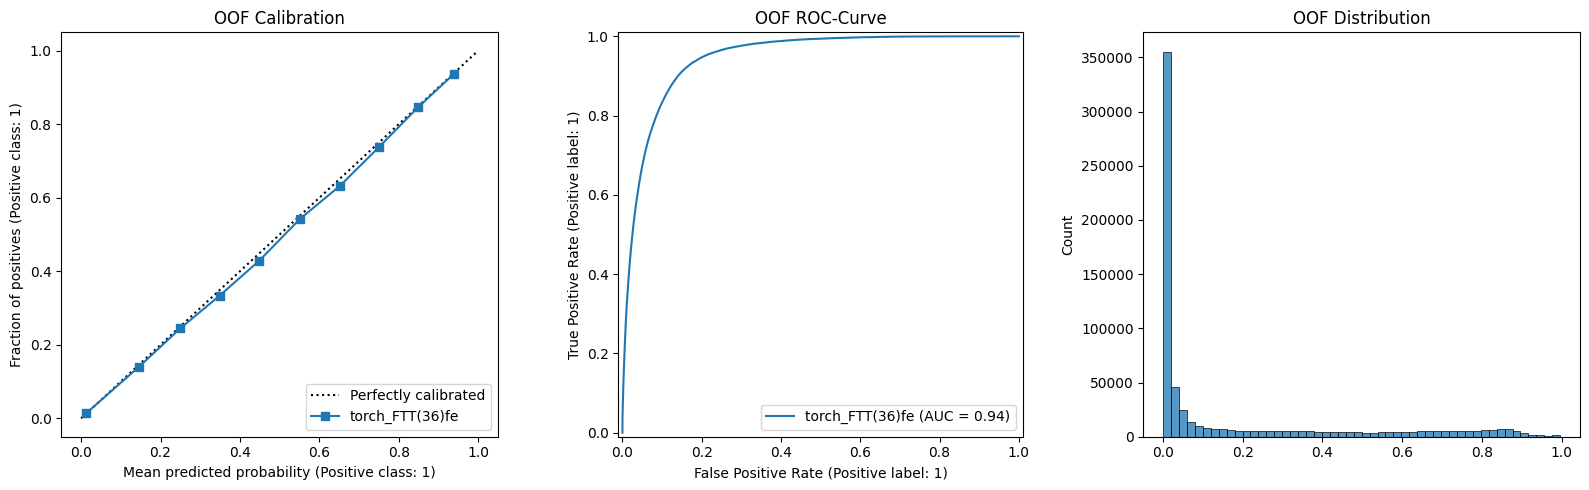

In [10]:
## -- Plot oof distributions --
_, axs = plt.subplots(1, 3, figsize=(16, 5))

CalibrationDisplay.from_predictions(y_1, oof_preds, n_bins=10, name=MODEL_NAME, ax=axs[0])
axs[0].set_title(f"OOF Calibration")

RocCurveDisplay.from_predictions(y_1, oof_preds, name=MODEL_NAME, ax=axs[1])
axs[1].set_title(f"OOF ROC-Curve")

sns.histplot(oof_preds, ax=axs[2], bins=50)
axs[2].set_title(f"OOF Distribution")

plt.tight_layout()
plt.show()

In [11]:
# !rm -r /kaggle/working/